# 13-2 이미지 정렬 트랜스포머, Q-Former

본 노트북은 13-2절 본문 예제([코드 13-9]~[코드 13-13])를 모아 직접 실행하고
검증한다. 대표적인 비전-언어 멀티모달 모델인 BLIP-2를 허깅페이스 transformers
라이브러리로 불러와 이미지 설명 생성과 시각 질의응답(VQA)을 수행하고,
모델 객체에서 비전 인코더 -> Q-Former -> 프로젝션 -> 언어 모델로 이어지는
데이터 흐름과 각 단계 텐서 크기를 직접 확인한다.

다루는 내용
- [코드 13-9] BLIP-2 모델과 프로세서 불러오기
- [코드 13-10] BLIP-2 모델을 사용해 이미지 설명 생성하기
- [코드 13-11] 시각 질의응답(VQA) 함수
- [코드 13-12] BLIP-2 모델의 구조 (발췌, 정리 - 실행하지 않음)
- [코드 13-13] BLIP-2 모델의 forward() 메서드 (발췌, 정리 - 실행하지 않음)

실습 환경 안내: BLIP-2(Salesforce/blip2-opt-2.7b)는 약 15GB의 저장 공간이
필요하며 첫 실행 시 모델을 내려받는다. GPU가 없으면 추론에도 상당한 시간이
걸릴 수 있어 구글 코랩 등 GPU 환경을 권장한다. GPU 메모리가 부족하면
`load_in_8bit=True` 옵션으로 사용량을 절반 이하로 줄일 수 있다.

이 장은 멀티모달 도메인을 다루므로, `MODEL_NAME` 등 상수는 공통 컨벤션을
따르되 `model`, `processor` 등 객체명과 `pixel_values`, `input_ids` 등
입력명은 허깅페이스 통용 표기를 그대로 사용한다(컨벤션 §12.4).

In [1]:
# 참고 - 라이브러리 설치 (이미 설치되어 있다면 건너뛰어도 좋다)
# !pip install -q accelerate pillow requests transformers

In [ ]:
# 참고 - 공통 라이브러리 경로 설정
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

viz.configure(save_grayscale=False)

In [ ]:
# 참고 - 라이브러리 import 와 시드 고정
SEED = 42
common.set_seed(SEED)
device = common.get_device()

In [ ]:
# # 참고 - 환경 설정 및 시드 고정
# import sys
# sys.path.append('../../')

# import random
# import warnings

# import numpy as np
# import torch

# from code_reference import common

# # 다운로드/로딩 시 경고 메시지를 줄인다 (정상 동작에는 영향 없음).
# warnings.filterwarnings('ignore')

# SEED = 42
# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)

# device = common.get_device()

CUDA를 사용합니다.


## 1. BLIP-2 모델 불러오기

허깅페이스 transformers 라이브러리로 BLIP-2를 불러온다. 멀티모달 모델도
12장의 LLM과 같은 인터페이스로 다룰 수 있다. 첫 실행에서는 약 15GB 분량의
가중치를 내려받으므로 시간이 걸리고, 두 번째 실행부터는 로컬 캐시에서 빠르게
로드된다.

In [ ]:
###############################################################################
# 코드 13-9 - BLIP-2 모델과 프로세서 불러오기
###############################################################################
from transformers import Blip2ForConditionalGeneration, Blip2Processor

MODEL_NAME = 'Salesforce/blip2-opt-2.7b'

# Blip2Processor: 이미지 전처리기 + 텍스트 토크나이저
# 12장의 AutoTokenizer 역할 + 13-1절의 CLIPProcessor의 역할
processor = Blip2Processor.from_pretrained(MODEL_NAME)

# torch_dtype: GPU 메모리 절약을 위해 16비트 부동소수점 사용
# device_map='auto': 모델을 GPU/CPU에 맞춰 자동 분산 배치
model = Blip2ForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if device.type == 'cuda' else torch.float32,
    device_map='auto',
)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f'BLIP-2 모델 로드 완료, 전체 파라미터 수: {total_params:,}')

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

BLIP-2 모델 로드 완료, 전체 파라미터 수: 3,744,761,856


In [4]:
# 참고 - [표 13-3] BLIP-2를 구성하는 요소별 파라미터 수 비교
# 학습 여부는 BLIP-2 학습 설계상의 구분이며, 추론용 코드에서는 동결하지 않는다.
components = {
    'ViT (고정)': model.vision_model,
    'Q-Former (학습)': model.qformer,
    '프로젝션 (학습)': model.language_projection,
    'OPT-2.7B (고정)': model.language_model,
}
total = 0
for name, module in components.items():
    n = common.count_params(module)
    total += n
    print(f'{name:<16}: {n:>13,}')
print(f'{"합계":<16}: {total:>13,}')

ViT (고정)        :   985,952,256
Q-Former (학습)   :   105,137,664
프로젝션 (학습)       :     1,968,640
OPT-2.7B (고정)   : 2,651,678,720
합계              : 3,744,737,280


## 2. 이미지 설명 생성과 시각 질의응답(VQA)

BLIP-2의 가장 기본적인 사용법인 이미지 설명 생성과 VQA를 수행한다. LLM의
답변 생성에 쓰던 generate() 메서드를 멀티모달 모델에도 그대로 사용한다.

In [5]:
# 코드 13-10 - BLIP-2 모델을 사용해 이미지 설명 생성하기
import requests
from PIL import Image

def load_image_from_url(url):
    return Image.open(requests.get(url, stream=True).raw).convert('RGB')

def caption_image(image, max_new_tokens=50):
    # 이미지만 입력하면 자유롭게 이미지 설명을 생성한다.
    inputs = processor(images=image, return_tensors='pt').to(
        device, torch.float16 if device.type == 'cuda' else torch.float32,
    )
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
    return processor.decode(output_ids[0], skip_special_tokens=True).strip()

# 세일즈포스가 공개한 샘플 이미지 (싱가포르 머라이언상)
image_url = ('https://storage.googleapis.com/sfr-vision-language-research/'
             'LAVIS/assets/merlion.png')
image = load_image_from_url(image_url)
print(caption_image(image))

singapore merlion fountain


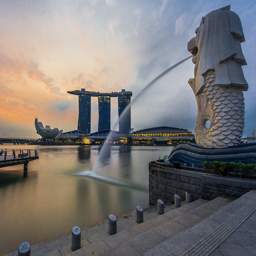

In [6]:
# 참고 - 사용한 샘플 이미지 표시
from IPython.display import display

display(image.resize((256, 256)))

In [7]:
# 코드 13-11 - 시각 질의응답(VQA) 함수
def ask(image, question, max_new_tokens=30):
    # BLIP-2 VQA는 'Question: ... Answer:' 형식 프롬프트를 사용한다.
    prompt = f'Question: {question} Answer:'
    inputs = processor(
        images=image, text=prompt, return_tensors='pt',
    ).to(device, torch.float16 if device.type == 'cuda' else torch.float32)
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
    decoded = processor.decode(output_ids[0], skip_special_tokens=True).strip()
    # 'Answer:' 구분자가 있으면 뒤쪽만 답변으로 사용, 없으면 프롬프트 제거
    if 'Answer:' in decoded:
        return decoded.split('Answer:', 1)[1].strip()
    if decoded.startswith(prompt):
        return decoded[len(prompt):].strip()
    return decoded

for q in ['What is in the image?', 'What city is this?',
          'What color is the water?']:
    print(f'Q: {q}')
    print(f'A: {ask(image, q)}')

Q: What is in the image?
A: The merlion fountain
Q: What city is this?
A: singapore
Q: What color is the water?
A: It's blue


## 3. BLIP-2의 내부 구조와 데이터 흐름

BLIP-2가 어떻게 이미지와 텍스트를 연결하는지 모델 객체에서 직접 확인한다.
핵심은 비전 인코더(ViT) -> Q-Former -> 프로젝션 계층 -> 언어 모델(OPT)로
이어지는 4단계 흐름이다.

먼저 [코드 13-12]는 허깅페이스 transformers의 `modeling_blip_2.py`에서
`Blip2ForConditionalGeneration.__init__()`의 핵심 구조를 읽기 좋게 발췌해
정리한 것이며, 실행하는 코드가 아니다(Apache License 2.0).

```python
# 코드 13-12 - BLIP-2 모델의 구조 (modeling_blip_2.py에서 발췌, 정리)
class Blip2ForConditionalGeneration(Blip2PreTrainedModel):
    def __init__(self, config):
        # 1) 비전 인코더 (ViT) - 이미지 -> 패치 임베딩 벡터
        self.vision_model = Blip2VisionModel(config.vision_config)
        # 2) 학습 가능한 쿼리 토큰 - 32개의 벡터, 각 768차원
        self.query_tokens = nn.Parameter(
            torch.zeros(1, config.num_query_tokens,
                        config.qformer_config.hidden_size)
        )
        # 3) Q-Former - 쿼리 토큰이 이미지 패치를 크로스 어텐션으로 참조
        self.qformer = Blip2QFormerModel(config.qformer_config)
        # 4) 프로젝션 계층 - Q-Former 출력(768) -> LLM 입력 차원(2560)
        self.language_projection = nn.Linear(
            config.qformer_config.hidden_size,   # 768
            config.text_config.hidden_size,      # 2560 (OPT-2.7B)
        )
        # 5) 언어 모델 (OPT-2.7B) - 이미지 표현 + 텍스트 -> 답변 생성
        self.language_model = OPTForCausalLM(config.text_config)
```

여기서 qformer와 language_projection이 함께 프로젝션 계층 역할을 한다.
차원 변환은 language_projection이, 이미지와 텍스트 정렬은 qformer가 담당한다.

다음 [코드 13-13]은 같은 파일의 forward() 메서드를 데이터 흐름 위주로
단순화한 것이다. 역시 실행하는 코드가 아니다. 실제 코드에는 어텐션 마스크,
학습 시 인과 마스킹 등 추가 요소가 더 포함되어 있다.

```python
# 코드 13-13 - BLIP-2 모델의 데이터 흐름 (modeling_blip_2.py에서 발췌, 정리)
def forward(self, pixel_values, input_ids, ...):
    # 1) 비전 인코더 - 이미지 -> 패치 임베딩
    vision_outputs = self.vision_model(pixel_values=pixel_values)
    image_embeds = vision_outputs.last_hidden_state    # (B, 257, 1408)
    B = image_embeds.shape[0]                           # 배치 크기
    # 2) Q-Former - 32개 쿼리가 이미지 패치를 크로스 어텐션으로 참조
    query_tokens = self.query_tokens.expand(B, -1, -1)  # (B, 32, 768)
    query_outputs = self.qformer(
        query_embeds=query_tokens,
        encoder_hidden_states=image_embeds,             # 키/값 = 이미지 패치
    )
    query_output = query_outputs.last_hidden_state      # (B, 32, 768)
    # 3) 프로젝션 - Q-Former 출력 -> LLM 입력 차원
    language_model_inputs = self.language_projection(query_output)
    # (B, 32, 2560)
    # 4) 언어 모델 - 이미지 표현(32토큰) + 텍스트 프롬프트 -> 답변 생성
    outputs = self.language_model(
        inputs_embeds=language_model_inputs, ...
    )
    # 실제로는 이 뒤에 텍스트 토큰 임베딩을 결합한 후 LLM에 전달한다
```

이 흐름을 실제 모델 객체에서 직접 확인해, 각 단계 출력의 텐서 크기를
살펴본다(배치 크기 1 기준).

In [8]:
# 참고 - 실제 모델의 중간 출력 크기 확인 (배치 크기 1)
inputs = processor(images=image, return_tensors='pt').to(
    device, torch.float16 if device.type == 'cuda' else torch.float32,
)
with torch.no_grad():
    # 1단계: 비전 인코더 출력
    vision_out = model.vision_model(pixel_values=inputs['pixel_values'])
    image_embeds = vision_out.last_hidden_state
    # 2단계: Q-Former 출력
    query_tokens = model.query_tokens.expand(image_embeds.shape[0], -1, -1)
    image_atts = torch.ones(
        image_embeds.size()[:-1], dtype=torch.long, device=image_embeds.device,
    )
    qformer_out = model.qformer(
        query_embeds=query_tokens,
        encoder_hidden_states=image_embeds,
        encoder_attention_mask=image_atts,
    )
    query_output = qformer_out.last_hidden_state
    # 3단계: 프로젝션 출력 - Q-Former 출력과 프로젝션 가중치의 dtype/device 정렬
    projection_weight = model.language_projection.weight
    query_output = query_output.to(
        device=projection_weight.device, dtype=projection_weight.dtype,
    )
    projected = model.language_projection(query_output)

print('각 단계별 텐서 크기 (배치 크기 1 기준):')
print(f'  1단계 비전 인코더 출력: {tuple(image_embeds.shape)}')
print(f'  2단계 Q-Former 출력:    {tuple(query_output.shape)}')
print(f'  3단계 프로젝션 출력:    {tuple(projected.shape)}')

각 단계별 텐서 크기 (배치 크기 1 기준):
  1단계 비전 인코더 출력: (1, 257, 1408)
  2단계 Q-Former 출력:    (1, 32, 768)
  3단계 프로젝션 출력:    (1, 32, 2560)


## 정리

- BLIP-2는 13-1절의 기본 골격(고정된 비전 인코더 + 고정된 언어 모델 +
  학습 가능한 작은 연결 고리)을 따르되, 단순한 다층 퍼셉트론 대신 Q-Former라는
  작은 트랜스포머를 연결 고리로 둔다.
- Q-Former의 학습 가능한 32개 쿼리 토큰이 257개의 이미지 패치 임베딩을
  크로스 어텐션으로 참조해 핵심 정보를 32개의 벡터로 압축하고, 선형 프로젝션
  계층이 이를 언어 모델 입력 차원(2560)에 맞춰 정렬한다.
- 13-1절과 마찬가지로 언어 모델에 input_ids 대신 inputs_embeds를 직접
  넘겨, 이미지에서 뽑은 32개의 힌트를 본 뒤 텍스트 토큰을 이어 보는 흐름이다.
- 허깅페이스 transformers 라이브러리를 통해 이미지 설명 생성과 VQA를
  12장의 LLM과 같은 인터페이스로 사용할 수 있다.